##  TITANIC_EDA

ADVAITH G

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Import Dataset**

In [3]:
from pathlib import Path

data_path = Path('data') / 'Titanic-Dataset.csv'
if not data_path.exists():
    data_path = Path('..') / 'data' / 'Titanic-Dataset.csv'

df = pd.read_csv(data_path)


**Dataset Overview**

In [4]:
print("Dataset Shape :", df.shape)
df.head()

Dataset Shape : (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


he dataset contains 891 passengers.
Around 38% survived, while 62% did not.
Most passengers were in third class.
The average passenger age is about 29 years, and the age distribution is likely right-skewed.
Most passengers traveled alone, with only a few traveling in large family groups.
Ticket fares are highly right-skewed and likely contain outliers.

**Data Quality**

In [7]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

<Axes: >

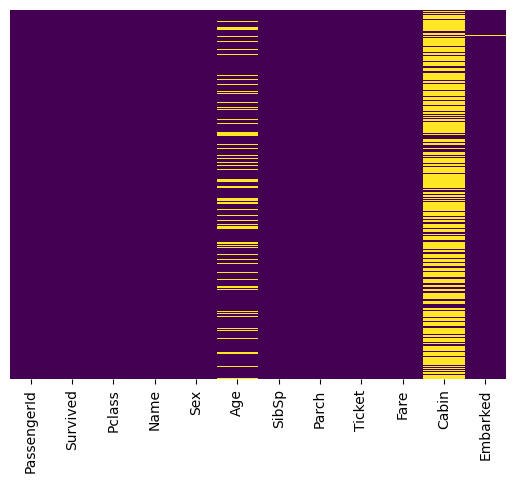

In [9]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

**FILL MISSING VALUES**

In [10]:
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [11]:
df['Embarked'].fillna(
    df['Embarked'].mode()[0],
    inplace=True
)

C:\Users\ADVAITH G\AppData\Local\Temp\ipykernel_16136\108396145.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(


In [12]:
df['HasCabin'] = df['Cabin'].notnull().astype(int)

In [13]:
df['HasCabin'].value_counts()

HasCabin
0    687
1    204
Name: count, dtype: int64

In [14]:
df.drop(columns='Cabin', inplace=True)

In [15]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64

In [16]:
print("Dataset Shape :", df.shape)

df.head()


Dataset Shape : (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


- Filled missing Age values using the median age within each passenger class.
- Filled missing Embarked values using the mode.
- Created a new feature `HasCabin` to preserve cabin information.
- Dropped the Cabin column due to a high percentage of missing values.
- Checked for duplicate records.
- Verified that the cleaned dataset contains no missing values.

**UNIVARIATE ANALYSIS**

**UNIVARIATE CAT COLS**

Variable: Survived

Value Counts:
Survived
0    549
1    342
Name: count, dtype: int64

Percentage Distribution:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


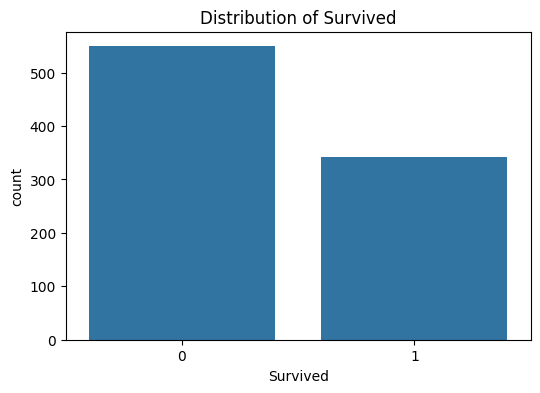

Variable: Pclass

Value Counts:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Percentage Distribution:
Pclass
3    55.11
1    24.24
2    20.65
Name: proportion, dtype: float64


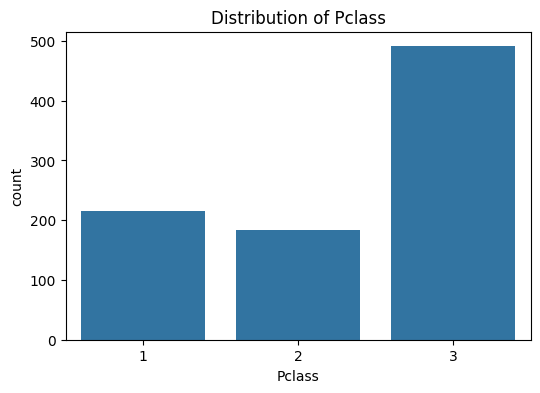

Variable: Sex

Value Counts:
Sex
male      577
female    314
Name: count, dtype: int64

Percentage Distribution:
Sex
male      64.76
female    35.24
Name: proportion, dtype: float64


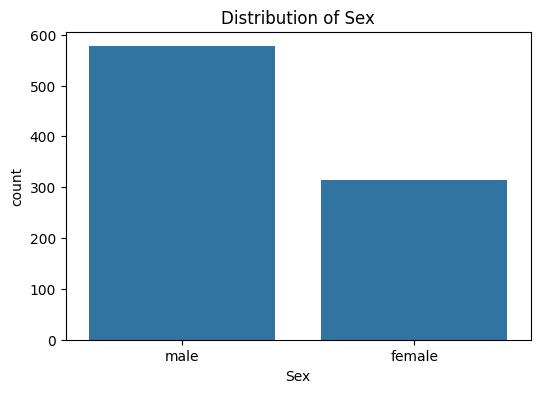

Variable: Embarked

Value Counts:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

Percentage Distribution:
Embarked
S    72.50
C    18.86
Q     8.64
Name: proportion, dtype: float64


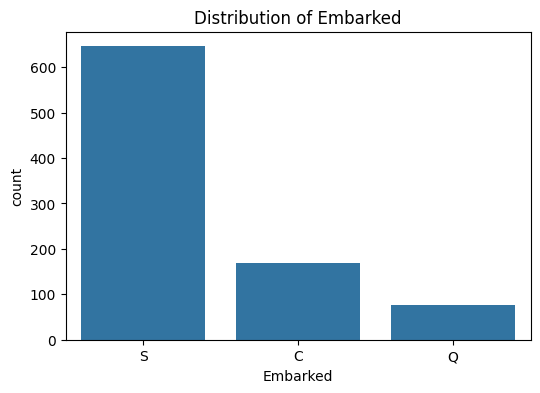

Variable: HasCabin

Value Counts:
HasCabin
0    687
1    204
Name: count, dtype: int64

Percentage Distribution:
HasCabin
0    77.1
1    22.9
Name: proportion, dtype: float64


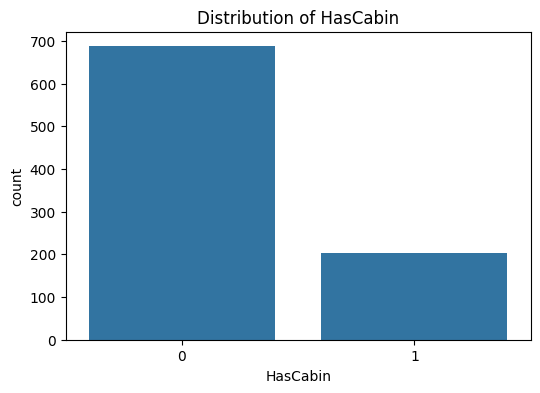


Name Summary
Unique Names: 891

Ticket Summary
Unique Tickets: 681
Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
113760          4
19950           4
Name: count, dtype: int64


In [17]:
categorical_cols = ['Survived', 'Pclass', 'Sex', 'Embarked']

if 'HasCabin' in df.columns:
    categorical_cols.append('HasCabin')

for col in categorical_cols:

    print("=" * 60)
    print(f"Variable: {col}")
    print("=" * 60)

    print("\nValue Counts:")
    print(df[col].value_counts())

    print("\nPercentage Distribution:")
    print(round(df[col].value_counts(normalize=True) * 100, 2))

    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)

    plt.title(f"Distribution of {col}")
    plt.show()

# High-cardinality columns
print("\nName Summary")
print("Unique Names:", df['Name'].nunique())

print("\nTicket Summary")
print("Unique Tickets:", df['Ticket'].nunique())
print(df['Ticket'].value_counts().head(10))

**UNIVARIATE - NUMERICAL COLS**

Variable: Age
count    891.000000
mean      29.066409
std       13.244532
min        0.420000
25%       22.000000
50%       26.000000
75%       37.000000
max       80.000000
Name: Age, dtype: float64


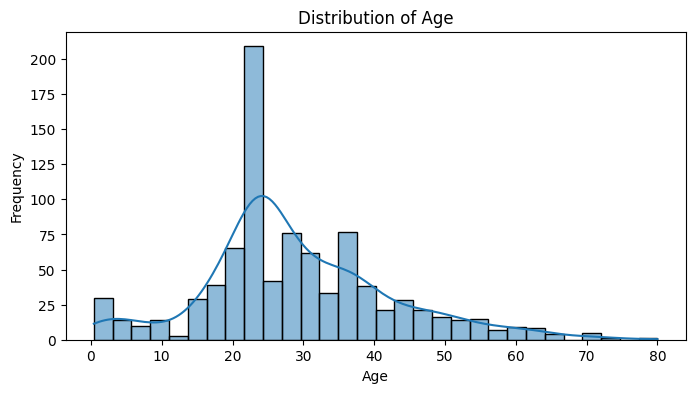

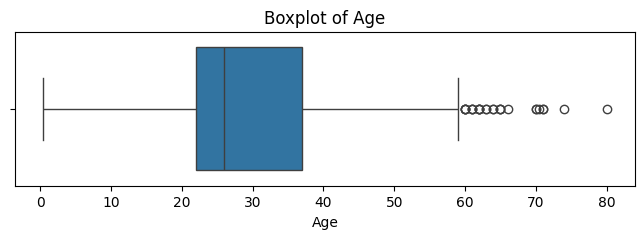

Variable: Fare
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


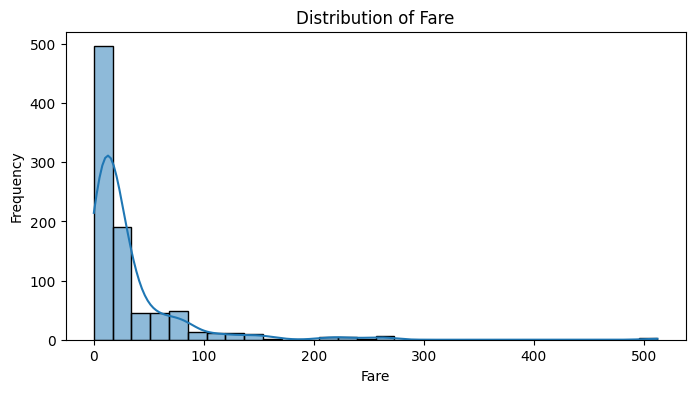

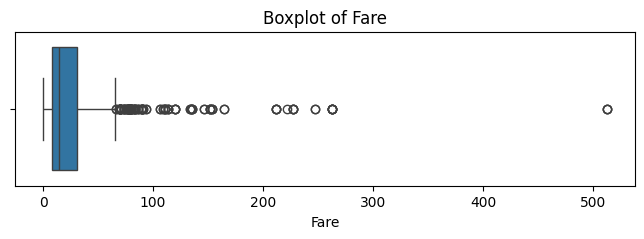

Variable: SibSp
count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64


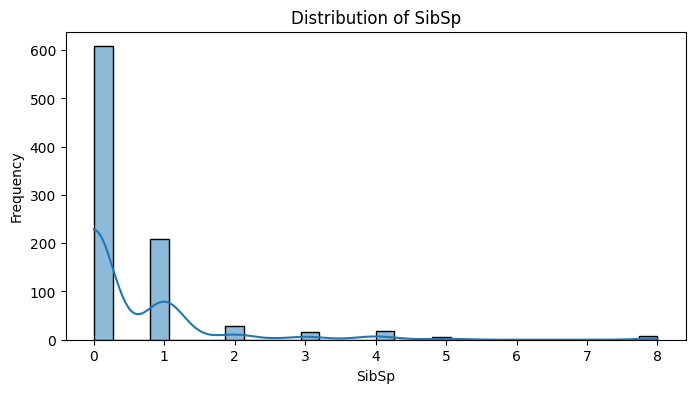

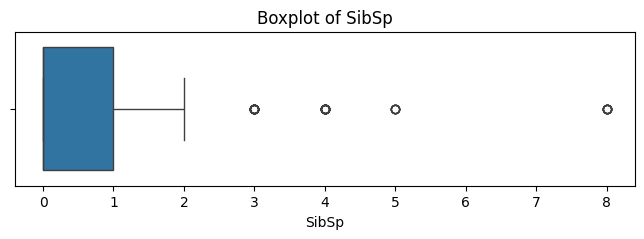

Variable: Parch
count    891.000000
mean       0.381594
std        0.806057
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: Parch, dtype: float64


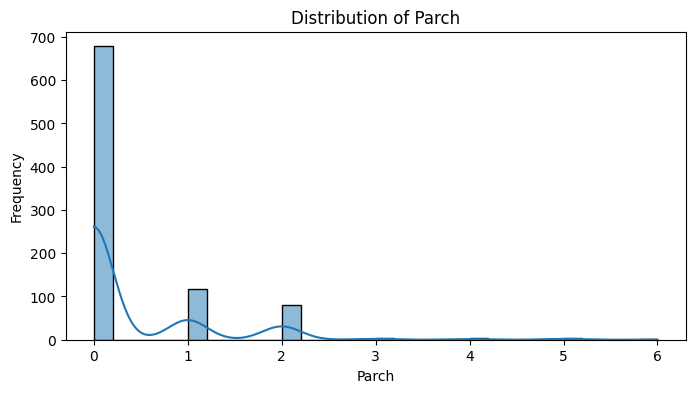

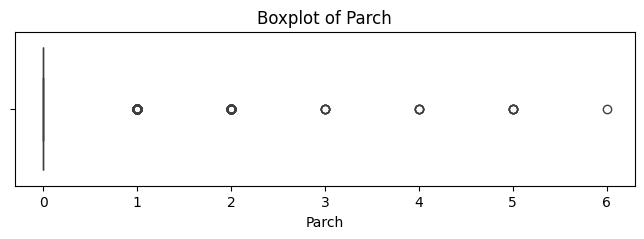

In [18]:
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

for col in numerical_cols:

    print("=" * 60)
    print(f"Variable: {col}")
    print("=" * 60)

    # Summary Statistics
    print(df[col].describe())

    # Histogram
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=30, kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    # Boxplot
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.show()

**OUTLIER DETECTION**

Boxplot for Age


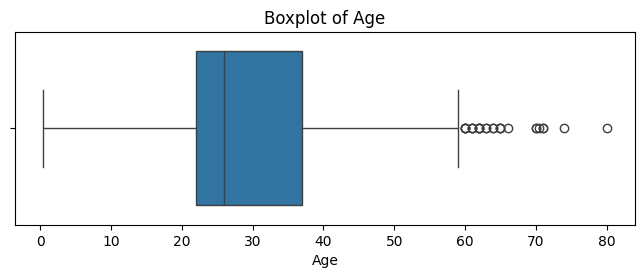

Boxplot for Fare


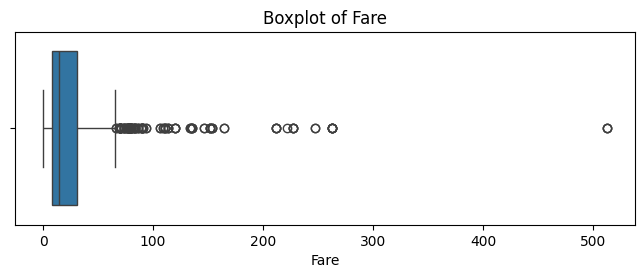

In [19]:
numerical_cols = ['Age', 'Fare']

for col in numerical_cols:

    print("=" * 50)
    print(f"Boxplot for {col}")
    print("=" * 50)

    plt.figure(figsize=(8, 2.5))
    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.show()

**Age:**
A few passengers have ages much higher than the majority.
These represent potential outliers.


**Fare:**
Several passengers paid exceptionally high fares.
The distribution contains many potential outliers.

In [20]:
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print("=" * 50)
    print(f"Outlier Analysis: {column}")
    print("=" * 50)

    print(f"Q1           : {Q1:.2f}")
    print(f"Q3           : {Q3:.2f}")
    print(f"IQR          : {IQR:.2f}")
    print(f"Lower Bound  : {lower_bound:.2f}")
    print(f"Upper Bound  : {upper_bound:.2f}")
    print(f"Outliers     : {len(outliers)}")
    print(f"Percentage   : {(len(outliers)/len(df))*100:.2f}%")

    return outliers

In [33]:
age_outliers = detect_outliers(df, 'Age')

fare_outliers = detect_outliers(df, 'Fare')

Outlier Analysis: Age
Q1           : 22.00
Q3           : 37.00
IQR          : 15.00
Lower Bound  : -0.50
Upper Bound  : 59.50
Outliers     : 26
Percentage   : 2.92%
Outlier Analysis: Fare
Q1           : 7.91
Q3           : 31.00
IQR          : 23.09
Lower Bound  : -26.72
Upper Bound  : 65.63
Outliers     : 116
Percentage   : 13.02%


### Interpretation

#### Age
- The IQR method identified 26 outliers (2.92%).
- These correspond to elderly passengers with ages above 59.5 years.
- Since these are genuine observations, they were retained.

#### Fare
- The IQR method identified 116 outliers (13.02%).
- These represent passengers who paid unusually high fares, primarily those traveling in first class.
- These values are valid and were retained.

**BIVARIATE ANALYSIS**

Survived vs Sex


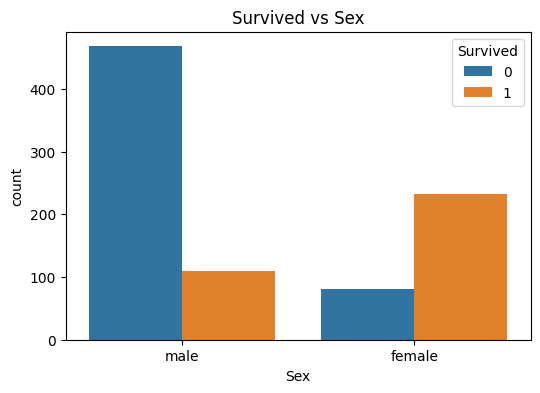

Survived    0    1
Sex               
female     81  233
male      468  109


Survived vs Pclass


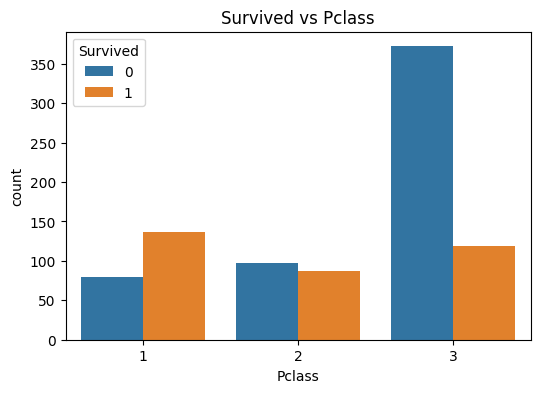

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


Survived vs Embarked


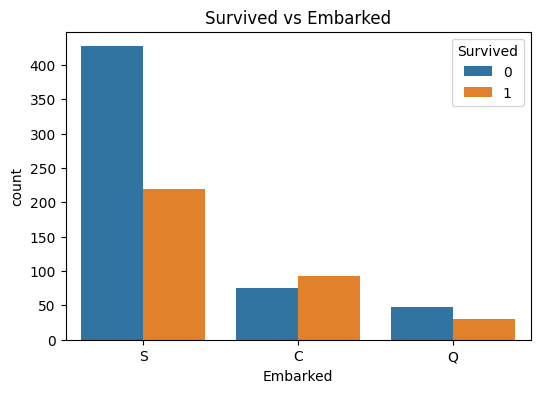

Survived    0    1
Embarked          
C          75   93
Q          47   30
S         427  219


Survived vs HasCabin


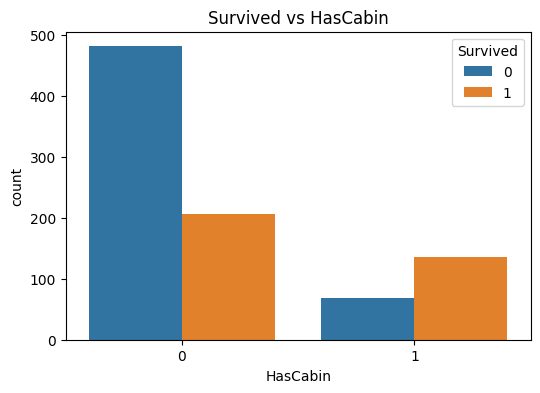

Survived    0    1
HasCabin          
0         481  206
1          68  136




In [21]:
categorical_cols = ['Sex', 'Pclass', 'Embarked']

# Add HasCabin if it exists
if 'HasCabin' in df.columns:
    categorical_cols.append('HasCabin')

for col in categorical_cols:

    print("=" * 50)
    print(f"Survived vs {col}")
    print("=" * 50)

    # Count Plot
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='Survived')

    plt.title(f"Survived vs {col}")
    plt.show()

    # Cross Tabulation
    print(pd.crosstab(df[col], df['Survived']))
    print("\n")

Age vs Survived


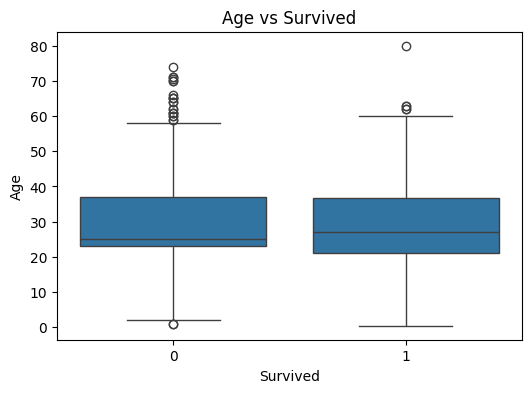

Fare vs Survived


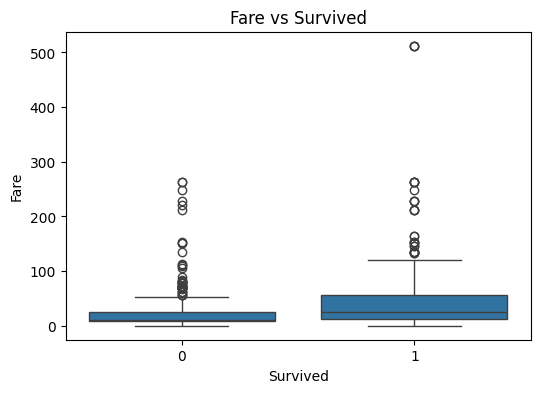

Age vs Pclass


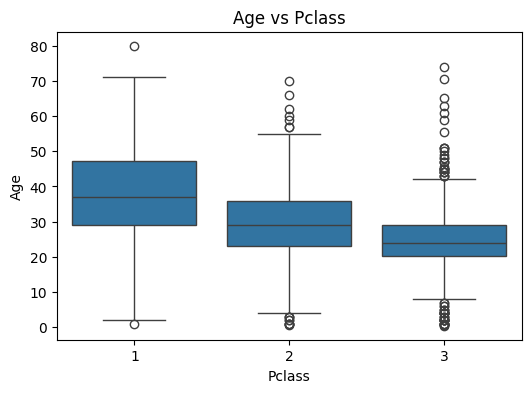

Fare vs Pclass


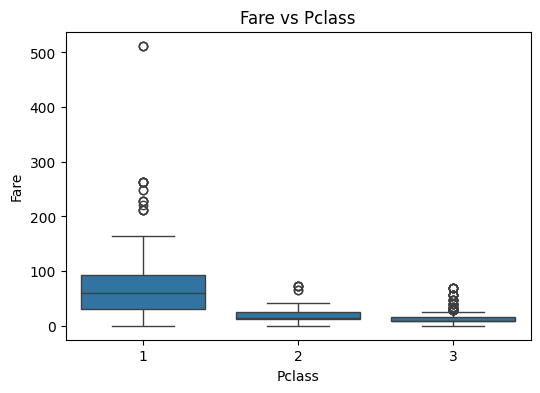

In [22]:
plots = [
    ('Survived', 'Age'),
    ('Survived', 'Fare'),
    ('Pclass', 'Age'),
    ('Pclass', 'Fare')
]

for x_col, y_col in plots:

    print("=" * 50)
    print(f"{y_col} vs {x_col}")
    print("=" * 50)

    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=x_col, y=y_col)

    plt.title(f"{y_col} vs {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.show()

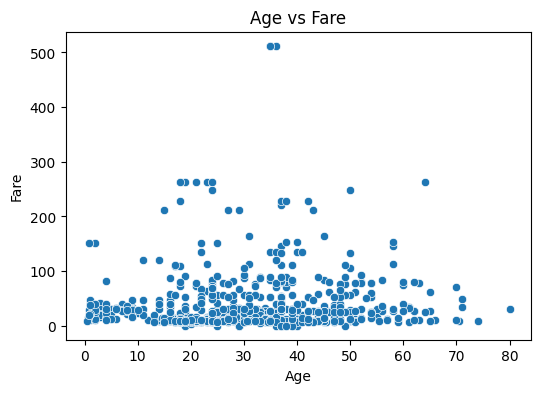

In [23]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Age', y='Fare')

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

**CORRELATION**

In [24]:
corr_matrix = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()

print(corr_matrix)

          Survived    Pclass       Age     SibSp     Parch      Fare
Survived  1.000000 -0.338481 -0.047255 -0.035322  0.081629  0.257307
Pclass   -0.338481  1.000000 -0.408487  0.083081  0.018443 -0.549500
Age      -0.047255 -0.408487  1.000000 -0.243526 -0.171095  0.123784
SibSp    -0.035322  0.083081 -0.243526  1.000000  0.414838  0.159651
Parch     0.081629  0.018443 -0.171095  0.414838  1.000000  0.216225
Fare      0.257307 -0.549500  0.123784  0.159651  0.216225  1.000000


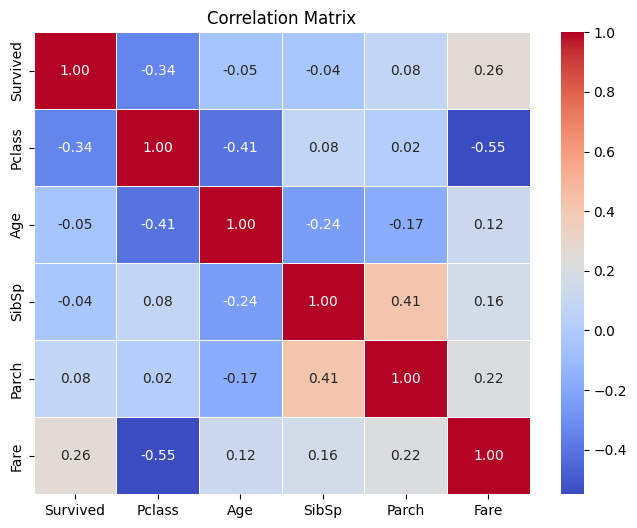

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis

- Survival has a moderate negative correlation with Passenger Class (-0.34), indicating that first-class passengers were more likely to survive.
- Fare has a weak positive correlation with Survival (0.26), suggesting passengers who paid higher fares had better survival chances.
- Passenger Class and Fare have the strongest relationship (-0.55), showing that higher-class passengers generally paid higher fares.
- SibSp and Parch are moderately positively correlated (0.41), indicating that passengers traveling with siblings or spouses often traveled with parents or children as well.
- Age has a moderate negative correlation with Passenger Class (-0.41), suggesting first-class passengers tended to be older.
- Most other feature pairs have weak correlations, indicating little or no linear relationship.

## **CHI_SQUARE TEST**

PCLASS VS SURVIVAL

Overall survival rate:

342 / 891 = 38.4%

Overall non-survival rate:

549 / 891 = 61.6%

So if passenger class didn't matter:

About 38.4% of each class should survive.
About 61.6% of each class should not survive.

In [26]:
from scipy.stats import chi2_contingency

# Create Contingency Table
contingency_table = pd.crosstab(df['Pclass'], df['Survived'])

print("Contingency Table")
print(contingency_table)
print()

# Perform Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-value              : {p_value:.6f}")
print(f"Degrees of Freedom   : {dof}")

alpha = 0.05

print()

if p_value < alpha:
    print("Decision : Reject H0")
    print("Conclusion : Passenger Class and Survival are significantly associated.")
else:
    print("Decision : Fail to Reject H0")
    print("Conclusion : No significant association between Passenger Class and Survival.")

Contingency Table
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

Chi-Square Statistic : 102.8890
P-value              : 0.000000
Degrees of Freedom   : 2

Decision : Reject H0
Conclusion : Passenger Class and Survival are significantly associated.


H0 if pclass and survival are not related

Class 1 → ~38%

Class 2 → ~38%

Class 3 → ~38%

But what actually happened after chi-square Test?

Class 1 → 63%

Class 2 → 47%

Class 3 → 24%

These observed percentages are very different from what we'd expect under the null hypothesis.

In [ ]:
from scipy.stats import chi2_contingency

# Contingency Table
contingency_table = pd.crosstab(df['Sex'], df['Survived'])

print("Contingency Table")
print(contingency_table)
print()

# Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-value              : {p_value:.6f}")
print(f"Degrees of Freedom   : {dof}")

alpha = 0.05

print()

if p_value < alpha:
    print("Decision : Reject H0")
    print("Conclusion : Sex and Survival are significantly associated.")
else:
    print("Decision : Fail to Reject H0")
    print("Conclusion : No significant association between Sex and Survival.")

Contingency Table
Survived    0    1
Sex               
female     81  233
male      468  109

Chi-Square Statistic : 260.7170
P-value              : 0.000000
Degrees of Freedom   : 1

Decision : Reject H0
Conclusion : Sex and Survival are significantly associated.


**T-TEST**

In [ ]:
from scipy.stats import ttest_ind

# Split the groups
survived = df[df['Survived'] == 1]['Age']
not_survived = df[df['Survived'] == 0]['Age']

# Perform Welch's t-test
t_stat, p_value = ttest_ind(
    survived,
    not_survived,
    equal_var=False
)

print(f"T-Statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")

alpha = 0.05

print()  

if p_value < alpha:
    print("Decision : Reject H0")
    print("Conclusion : The mean age differs significantly between survivors and non-survivors.")
else:
    print("Decision : Fail to Reject H0")
    print("Conclusion : No significant difference in mean age between survivors and non-survivors.")

T-Statistic : -1.3823
P-value     : 0.167345

Decision : Fail to Reject H0
Conclusion : No significant difference in mean age between survivors and non-survivors.


### Independent Samples t-Test (Age vs Survival)

**Null Hypothesis (H₀):**
The mean age of survivors and non-survivors is equal.

**Alternative Hypothesis (H₁):**
The mean age of survivors and non-survivors is different.

**Results**

- T-statistic = -1.3823
- P-value = 0.1673

Since the p-value (0.1673) is greater than the significance level (0.05), we fail to reject the null hypothesis.

**Conclusion:**

There is insufficient statistical evidence to conclude that the mean age of survivors differs significantly from the mean age of non-survivors.

In [50]:
print("Mean Age of Survivors      :", survived.mean())
print("Std Dev of Survivors       :", survived.std())

print()

print("Mean Age of Non-Survivors  :", not_survived.mean())
print("Std Dev of Non-Survivors   :", not_survived.std())

Mean Age of Survivors      : 28.27388888888889
Std Dev of Survivors       : 13.942808332148571

Mean Age of Non-Survivors  : 29.560109289617486
Std Dev of Non-Survivors   : 12.778433044897348


## Summary of Key Findings
- Dropped cabin and created a hascabin to preserve some information
- Female passengers had a significantly higher survival rate than male passengers, confirmed by the Chi-Square test.
- First-class passengers were much more likely to survive than second- and third-class passengers.
- The Fare distribution was highly right-skewed, while Age was approximately normally distributed.
- Although survivors were slightly younger on average than non-survivors, the difference was not statistically significant (p > 0.05) and was confirmed by T-Test.
- Missing values were handled appropriately, and no outliers were removed because they represented valid passenger records.

In [ ]:
from pathlib import Path

output_path = Path('data') / 'preprocessed_titanic.csv'
if not output_path.parent.exists():
    output_path = Path('..') / 'data' / 'preprocessed_titanic.csv'

df.to_csv(output_path, index=False)
print(f'Preprocessed dataset saved to: {output_path}')
print(f'Shape: {df.shape}')
